In [1]:
!pip install -q transformers accelerate Pillow matplotlib
!pip install -U "bitsandbytes>=0.46.1"
!git clone https://github.com/sht037-lgtm/Q-Vtree.git
%cd Q-Vtree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.7 MB/s eta 0:00:00:00:0100:01
Cloning into 'Q-Vtree'...
remote: Enumerating objects: 1510, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 1510 (delta 35), reused 42 (delta 21), pack-reused 1453 (from 2)
Receiving objects: 100% (1510/1510), 38.15 MiB | 51.68 MiB/s, done.
Resolving deltas: 100% (950/950), done.
/kaggle/working/Q-Vtree


In [ ]:
from transformers import LlavaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch

model_id  = "llava-hf/llava-1.5-7b-hf"
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="eager",
)
model.eval()
print("Model loaded")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Image size: (1024, 593)


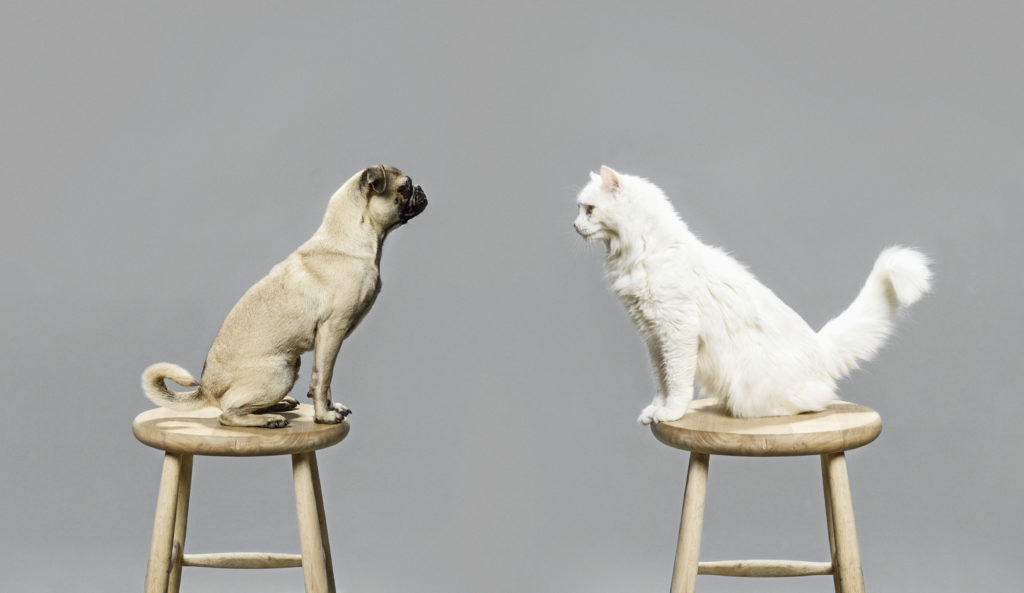

In [5]:
from PIL import Image

image    = Image.open("img/demo_12.jpeg").convert("RGB")
question = (
    "What is the kind of the dog?\n"
  
)
print("Image size:", image.size)
image

import 成功
CLIP image size: (336, 336)
[DEBUG] answer = 'The dog is a pug.'
[DEBUG] seq_len=597, img_end=580
[DEBUG] text tokens: 16 tokens
[DEBUG] A_q  max=0.008822, mean=0.00023865
[DEBUG] generic: 8 tokens, gen_seq_len=595
[DEBUG] A_g  max=0.008299, mean=0.00031353
[DEBUG] relative max=3.5685, mean=0.547740
[INFO] Saved to attention_map_final.png


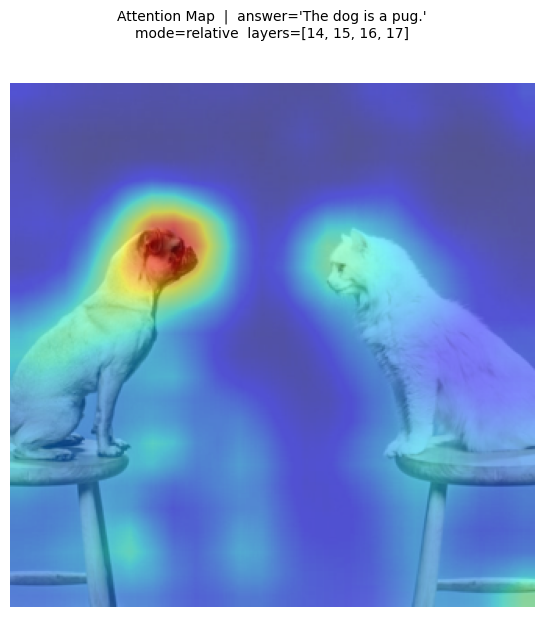

In [6]:
import subprocess, importlib.util, sys, torch
import torchvision.transforms.functional as TF

# ===== 1. 强制拉最新代码 =====
subprocess.run(["git", "-C", "/kaggle/working/Q-Vtree", "fetch", "origin"], capture_output=True)
subprocess.run(["git", "-C", "/kaggle/working/Q-Vtree", "reset", "--hard", "origin/main"], capture_output=True)

def load_attention_viz():
    spec = importlib.util.spec_from_file_location(
        "attention_viz_fresh",
        "/kaggle/working/Q-Vtree/LLaVA/attention_viz.py"
    )
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

av = load_attention_viz()
get_attention_maps = av.get_attention_maps
visualize_attention = av.visualize_attention
print("import success")

# ===== 2. 还原 CLIP 实际看到的图片 =====
prompt = f"USER: <image>\n{question}\nASSISTANT:"
inputs_check = processor(
    text=prompt,
    images=image.convert("RGB"),
    return_tensors="pt",
)
pixel_values = inputs_check["pixel_values"][0].cpu().float()
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1)
std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)
clip_image = (pixel_values * std + mean).clamp(0, 1)
clip_image = TF.to_pil_image(clip_image)
print("CLIP image size:", clip_image.size)

# ===== 3. 计算 attention map =====
attn_result = get_attention_maps(
    model=model,
    processor=processor,
    image=image,
    question=question,
    target_layers=(14, 15, 16, 17),
    use_relative=True,
)

# ===== 4. 可视化（用 CLIP 图，空间对齐更准确）=====
visualize_attention(
    image=clip_image,
    attn_result=attn_result,
    alpha=0.5,
    save_path="attention_map_final.png",
)